In [1]:
from urllib.request import urlopen
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import defaultdict

## Function that allows us to automate calls to the API so that we can extract data fro Large Data Sets ##


In [2]:
def get_blast_info(sn_name):
    """
    Fetch information for a supernova/transient from the BLAST API.

    Parameters
    ----------
    sn_name : str
        The supernova/transient name (e.g. "2004ef").

    Returns
    -------
    tuple
        (row_dict, missing_name_or_None)
        - On success: (dict of BLAST fields, None)
        - On failure: ({}, sn_name)
    """

    url = f"https://blast.ncsa.illinois.edu/api/transient/get/{sn_name}?format=json"
    try:
        with urlopen(url) as r:
            payload = json.loads(r.read())
    
    ## The following catches any Python Exception that happened within the "try" block.
    ## Error object gets stored as the variable e.
    ## Also keeps track of missing supernova names. Upon exceptions being thrown, ends up returning just
    ## the string that is the SNIa name. 
    except Exception as e:
        print(f"Error fetching {sn_name}: {e}")
        return {}, sn_name

    row = {
        "blast_transient_spectroscopic_class": (payload.get("transient_spectroscopic_class") or "").strip(),
        "blast_transient_photometric_class": (payload.get("transient_photometric_class") or "").strip(),
        
        "blast_host_name": payload.get("host_name"),
        "blast_host_ra_deg": payload.get("host_ra_deg"),
        "blast_host_dec_deg": payload.get("host_dec_deg"),
        "blast_host_redshift": payload.get("host_redshift"),
        "blast_host_EBV_MW": payload.get("host_milkyway_dust_reddening"),

        # Local SED
        "blast_local_log_mass_50": payload.get("local_aperture_host_log_mass_50"),
        "blast_local_log_sfr_50": payload.get("local_aperture_host_log_sfr_50"),
        "blast_local_log_ssfr_50": payload.get("local_aperture_host_log_ssfr_50"),
        "blast_local_log_age_50": payload.get("local_aperture_host_log_age_50"),
        "blast_local_mass_surviving_ratio": payload.get("local_aperture_host_mass_surviving_ratio"),

        # Global SED
        "blast_global_log_mass_50": payload.get("global_aperture_host_log_mass_50"),
        "blast_global_log_sfr_50": payload.get("global_aperture_host_log_sfr_50"),
        "blast_global_log_ssfr_50": payload.get("global_aperture_host_log_ssfr_50"),
        "blast_global_log_age_50": payload.get("global_aperture_host_log_age_50"),
        "blast_global_mass_surviving_ratio": payload.get("global_aperture_host_mass_surviving_ratio"),
    }
    return row, None

## Querying the DES Catalog ##

No longer the best option/function to query the BLAST catalog. 

In [3]:
# # Load your CSV 
# csv_path = "data_ZTF/ZTF_snia_data.csv"
# df = pd.read_csv(csv_path)

# # Collect BLAST info
# blast_rows = []
# missing_from_blast = []

# # Can replace df["CID"] with whatever name df
# # has for the IAUA name 
# for sn in df["iau_name"]:
#     row, missing = get_blast_info(str(sn))  # ensure string format
#     blast_rows.append(row)
#     if missing:   # missing is sn_name or Non
#         missing_from_blast.append(missing)

# # Merge results back into DataFrame
# blast_df = pd.DataFrame(blast_rows)
# df = pd.concat([df, blast_df], axis=1)

# # Save to new file
# df.to_csv("data_ZTF/ZTF_BLAST_QUERY_v2.csv", index=False)

# print("Failed lookups:", missing_from_blast)

Now we will perform a quick sort that filters the .csv and splits it into what were were able to query from BLAST vs. what were wer not able to query from BLAST. 

# Problems with `iau_name` and `ztfname`

After submitting the tail end of the ZTF catalog to the BLAST API Query, I came to the realization that some IAU Names either did not exist or weere missing from the ZTF catalog. When submitting chunks of data to be analyzed through the BLAST API pipeline, i realized that I must include a safeguard. If the SNIa is not found by `iau_name` then check for the `ztfname` just in case. 

In [4]:
# Load your CSV 
csv_path = "data_ZTF/ZTF_snia_data.csv"
df = pd.read_csv(csv_path)

# Collect BLAST info
blast_rows = []
missing_from_blast = []

## new For loop iterates through each row of the data frame.
# .strip() removes any leading/trailing whitespace (just in case precaution).

for _, row in df.iterrows():
    sn_name = str(row.get("iau_name", "")).strip()
    ztf_name = str(row.get("ztfname", "")).strip()

    # First try IAU name
    blast_row, missing = get_blast_info(sn_name)

    # If that failed AND we have a ztfname, try again
    if (not blast_row) and ztf_name:
        blast_row, missing = get_blast_info(ztf_name)

    blast_rows.append(blast_row)

    if missing:   # if still missing, record it
        missing_from_blast.append(missing)

# Merge results back into DataFrame
blast_df = pd.DataFrame(blast_rows)
df = pd.concat([df, blast_df], axis=1)

# Save to new file
df.to_csv("data_ZTF/ZTF_BLAST_QUERY_v2.csv", index=False)

print("Failed query for both 'iau_name' and 'ztf_name':", missing_from_blast)

Error fetching nan: HTTP Error 404: Not Found
Error fetching nan: HTTP Error 404: Not Found


KeyboardInterrupt: 

# Problems with Host Galaxy Parameters as Returned from BLAST

Sometimes no parameters get returned, sometimes both local and global parameters get returned. Sometimes no parameters get returned. This code only checks based on the gaalxy extinction property which is precomputed no matter what. 

In [ ]:
# csv_in  = "data_ZTF/ZTF_BLAST_QUERY.csv"
# csv_out = "data_ZTF/ZTF_BLAST_matches_test.csv"
# csv_missing = "data_ZTF/ZTF_BLAST_umatched_test.csv"

# # Load
# df = pd.read_csv(csv_in)

# # All BLAST columns (those we added with the 'blast_' prefix)
# blast_cols = [c for c in df.columns if c.startswith("blast_")]

# # Mark rows that have at least ONE non-null BLAST value
# has_blast = df[blast_cols].notna().any(axis=1)

# # Keep only rows with BLAST info
# kept = df[has_blast].copy()

# # Rows removed = missing from BLAST entirely
# missing = df[~has_blast].copy()

# # (Optional) pick a likely name/ID column to show in the missing file
# name_col = next((c for c in ["CID", "SNID", "transient_name"] if c in df.columns), None)
# if name_col:
#     missing = missing[[name_col] + blast_cols]  # show identifier + the empty blast columns

# # Save results
# kept.to_csv(csv_out, index=False)
# missing.to_csv(csv_missing, index=False)

# print(f"Kept {len(kept)} rows with BLAST data → {csv_out}")
# print(f"Removed {len(missing)} rows missing BLAST data → {csv_missing}")

Kept 3158 rows with BLAST data → data_ZTF/ZTF_BLAST_matches_test.csv
Removed 470 rows missing BLAST data → data_ZTF/ZTF_BLAST_umatched_test.csv


In [ ]:
# csv_in       = "data_ZTF/ZTF_BLAST_QUERY.csv"
# csv_good_out = "data_ZTF/ZTF_BLAST_matches_props_v2.csv"
# csv_bad_out  = "data_ZTF/ZTF_BLAST_missing_props_v2.csv"

# # How many properties must be present to count as a "good" BLAST host row?
# MIN_PROPS_REQUIRED = 1  # change to 5 or 10 if you want stricter filtering

# # Load
# df = pd.read_csv(csv_in)

# # The host-galaxy properties you care about (local + global, medians)
# prop_cols = [
#     "blast_local_log_mass_50",
#     "blast_local_log_sfr_50",
#     "blast_local_log_ssfr_50",
#     "blast_local_log_age_50",
#     "blast_local_mass_surviving_ratio",
#     "blast_global_log_mass_50",
#     "blast_global_log_sfr_50",
#     "blast_global_log_ssfr_50",
#     "blast_global_log_age_50",
#     "blast_global_mass_surviving_ratio",
# ]

# # Keep only the props that actually exist in the file (avoid KeyErrors)
# props_present = [c for c in prop_cols if c in df.columns]
# if not props_present:
#     raise ValueError("None of the requested BLAST host-property columns are present in the CSV.")

# # Per-row completeness: how many of the requested props are non-null?
# df["_blast_prop_count"] = df[props_present].notna().sum(axis=1)

# # Good if row has at least MIN_PROPS_REQUIRED of the desired props
# mask_good = df["_blast_prop_count"] >= MIN_PROPS_REQUIRED
# good = df[mask_good].copy()
# bad  = df[~mask_good].copy()

# # (Optional) include helpful ID columns if they exist
# id_cols = [c for c in ["iau_name", "ztfname", "CID", "SNID", "transient_name"] if c in df.columns]
# cols_for_bad = id_cols + props_present if id_cols else props_present
# bad = bad[cols_for_bad + (["_blast_prop_count"] if "_blast_prop_count" in bad.columns else [])]

# # Save
# good.to_csv(csv_good_out, index=False)
# bad.to_csv(csv_bad_out, index=False)

# print(f"Rows with ≥{MIN_PROPS_REQUIRED} host props: {len(good)}  → {csv_good_out}")
# print(f"Rows with  <{MIN_PROPS_REQUIRED} host props: {len(bad)}   → {csv_bad_out}")

# # ---- Summary 1: per-field non-null counts & percentages ----
# total_rows = len(df)
# summary_counts = (
#     df[props_present].notna()
#       .sum()
#       .to_frame("non_null_count")
#       .assign(percent=lambda x: 100.0 * x["non_null_count"] / total_rows)
#       .sort_values("non_null_count", ascending=False)
# )
# print("\nPer-field availability (non-null):")
# print(summary_counts)

# # ---- Summary 2: completeness distribution (#props present per row) ----
# comp_dist = (
#     df["_blast_prop_count"]
#       .value_counts()
#       .sort_index()
#       .to_frame("rows")
# )
# comp_dist["percent"] = 100.0 * comp_dist["rows"] / total_rows
# print("\nCompleteness distribution (# of desired props present per row):")
# print(comp_dist)

# Solution From BLAST Matching

The fix here is to save a file with just host galaxy parameters, both local and global host galaxy parameters, and no parameters. 

In [5]:
import pandas as pd

csv_in = "data_ZTF/ZTF_BLAST_QUERY_v2.csv"

# Load
df = pd.read_csv(csv_in)

# The host-galaxy properties you care about (local + global, medians)
prop_cols = [
    "blast_local_log_mass_50",
    "blast_local_log_sfr_50",
    "blast_local_log_ssfr_50",
    "blast_local_log_age_50",
    "blast_local_mass_surviving_ratio",
    "blast_global_log_mass_50",
    "blast_global_log_sfr_50",
    "blast_global_log_ssfr_50",
    "blast_global_log_age_50",
    "blast_global_mass_surviving_ratio",
]

# --- Separate the host property columns into local vs global ---

# Start with empty lists
local_cols  = []
global_cols = []

# Go through each column name in the prop_cols list
for col in prop_cols:
    # If the column name contains "blast_local_", treat it as a local property
    if "blast_local_" in col:
        local_cols.append(col)
    
    # If the column name contains "blast_global_", treat it as a global property
    if "blast_global_" in col:
        global_cols.append(col)

        
# --- Precompute helpful counts ---
df["_blast_prop_count"]   = df[prop_cols].notna().sum(axis=1)
df["_local_prop_count"]   = df[local_cols].notna().sum(axis=1)
df["_global_prop_count"]  = df[global_cols].notna().sum(axis=1)

# --- Masks for the three outputs ---
mask_all_host      = df[prop_cols].notna().all(axis=1)          # all 10 present (local+global complete)
mask_global_only   = df[global_cols].notna().all(axis=1)        # all 5 global present (local may be missing)
mask_no_host_props = df["_blast_prop_count"] == 0               # none of the 10 present

# --- File names (adjust as you like) ---
csv_all_host   = "data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES.csv"
csv_global_any = "data_ZTF/ZTF_BLAST_matches_props_v2_GLOBAL_ONLY.csv"
csv_no_host    = "data_ZTF/ZTF_BLAST_matches_props_v2_NO_HOST.csv"

# --- Save (retain ALL columns) ---
df[mask_all_host].to_csv(csv_all_host, index=False)
df[mask_global_only].to_csv(csv_global_any, index=False)
df[mask_no_host_props].to_csv(csv_no_host, index=False)

# --- Quick printout ---
# :>6 right alling the number in a field thats 6 characters wide.
print(f"ALL host props (10/10): {mask_all_host.sum():>6} → {csv_all_host}")
print(f"GLOBAL complete (5/5), local optional: {mask_global_only.sum():>6} → {csv_global_any}")
print(f"NO host props (0/10): {mask_no_host_props.sum():>6} → {csv_no_host}")

ALL host props (10/10):   1310 → data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES.csv
GLOBAL complete (5/5), local optional:   1526 → data_ZTF/ZTF_BLAST_matches_props_v2_GLOBAL_ONLY.csv
NO host props (0/10):   2065 → data_ZTF/ZTF_BLAST_matches_props_v2_NO_HOST.csv


# Missing Light Curve Parameters # 

Looking at the matched data we end up finding out that certain entries have their light curve parameters missing and thus end up having to be removed. 

In [6]:
df = pd.read_csv("data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES.csv")

# Required light-curve parameters (values must be non-null)
lc_cols = [
    "t0", "x0", "x1", "c",
    "t0_err", "x0_err", "x1_err", "c_err",
    "cov_t0_x0", "cov_t0_x1", "cov_t0_c",
    "cov_x0_x1", "cov_x0_c", "cov_x1_c",
]

# Mask: row is "good" only if all required LC params are non-null
# note: axis = 1 means operate across the columns.
mask_complete = df[lc_cols].notna().all(axis=1)

good_lc = df[mask_complete].copy()
bad_lc  = df[~mask_complete].copy()

# For the "missing" set, list which LC params are missing on each row
# if statement here runs the block only if the condition is true. 

# Go through every column name c in lc_cols.
# Check pd.isna(row[c]).
# If True → include c in the output list.
# If False → skip it.
# Collect all the “missing” column names into a list.
# Return that list.
def list_missing(row):
    return [c for c in lc_cols if pd.isna(row[c])]

# Applies the list_missing function to each row of the bad_lc DataFrame.
# stores the return of the function in a new column called "_missing_lc_params" in the bad_lc DataFrame.
bad_lc["_missing_lc_params"] = bad_lc.apply(list_missing, axis=1)

# Save (keep ALL columns for full context)
good_lc.to_csv("data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_OK.csv", index=False)
bad_lc.to_csv("data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_MISSING.csv", index=False)

print(f"Rows with ALL LC params present: {len(good_lc)}  → data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_OK.csv")
print(f"Rows with ANY LC param missing: {len(bad_lc)}  → data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_MISSING.csv")

# Optional: quick per-field availability summary
summary = (
    df[lc_cols].notna().sum()
      .to_frame("non_null_count")
      .assign(percent=lambda x: 100 * x["non_null_count"] / len(df))
      .sort_values("non_null_count", ascending=False)
)
print("\nPer-field availability among rows in csv_good_out:")
print(summary)

Rows with ALL LC params present: 1279  → data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_OK.csv
Rows with ANY LC param missing: 31  → data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_MISSING.csv

Per-field availability among rows in csv_good_out:
           non_null_count    percent
t0                   1284  98.015267
x0                   1279  97.633588
x1                   1279  97.633588
c                    1279  97.633588
t0_err               1279  97.633588
x0_err               1279  97.633588
x1_err               1279  97.633588
c_err                1279  97.633588
cov_t0_x0            1279  97.633588
cov_t0_x1            1279  97.633588
cov_t0_c             1279  97.633588
cov_x0_x1            1279  97.633588
cov_x0_c             1279  97.633588
cov_x1_c             1279  97.633588


# Histogram Reprsenting Redshift Distribution of the ZTF Data Release Combined with the ZTF SNIa release that had host Galaxies Matched to them #

In this particular case, we are only looking for data that had both local and global galaxy parameters. 

3628 ZTF SNe Ia total
1279 matched with BLAST data


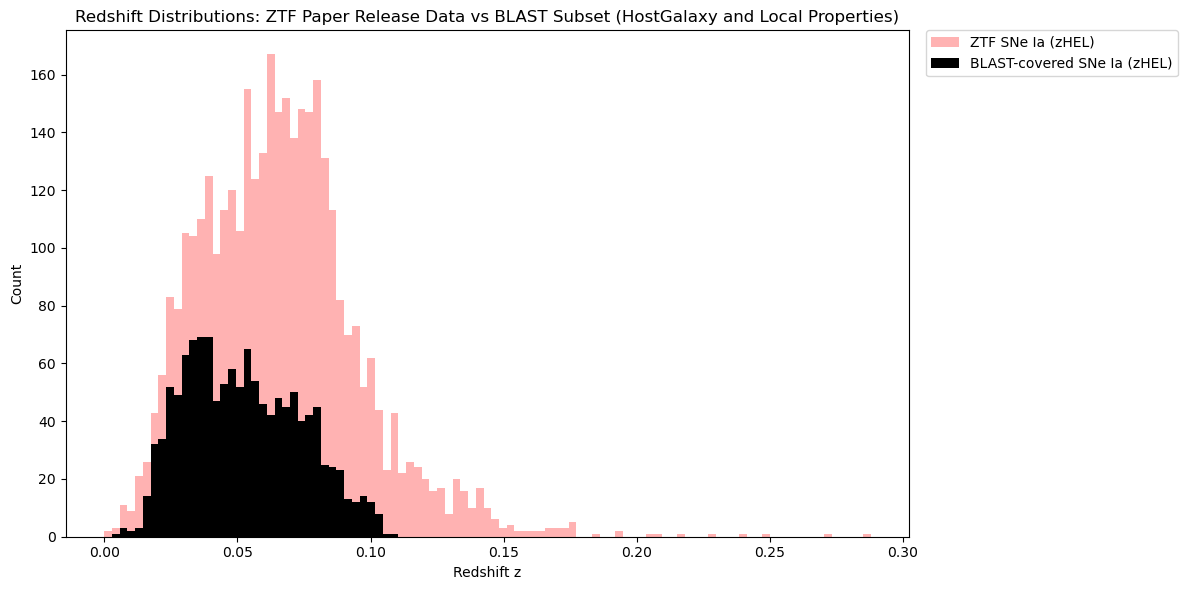

In [ ]:
DES_SN_CSV = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_snia_data.csv"
BLAST_CSV  = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_OK.csv"

# Load
ZTF_sn   = pd.read_csv(DES_SN_CSV)
blast_df = pd.read_csv(BLAST_CSV)

print(len(ZTF_sn), "ZTF SNe Ia total")
matched = len(blast_df)
print(matched, "matched with BLAST data")

z_all_des      = pd.to_numeric(ZTF_sn["redshift"])
z_blast_subset = pd.to_numeric(blast_df["redshift"])

# Shared binning — one line!
zmin = 0
zmax = z_all_des.max()
bins = np.linspace(zmin, zmax, 100)   # <-- control bins right here

plt.figure(figsize=(12, 6))
plt.hist(z_all_des,      bins=bins, alpha=0.3, label="ZTF SNe Ia (zHEL)", color = "red")
plt.hist(z_blast_subset, bins=bins, alpha=1, label="BLAST-covered SNe Ia (zHEL)", color = "black")

plt.xlabel("Redshift z")
plt.ylabel("Count")
plt.title("Redshift Distributions: ZTF Paper Release Data vs BLAST Subset (HostGalaxy and Local Properties)")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# Cleaning Missing LC entries from Data that only had Host Galaxy Properties Associated With them #

In [ ]:
df = pd.read_csv("/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_matches_props_v2_GLOBAL_ONLY.csv")

# Required light-curve parameters (values must be non-null)
lc_cols = [
    "t0", "x0", "x1", "c",
    "t0_err", "x0_err", "x1_err", "c_err",
    "cov_t0_x0", "cov_t0_x1", "cov_t0_c",
    "cov_x0_x1", "cov_x0_c", "cov_x1_c",
]

# Mask: row is "good" only if all required LC params are non-null
# note: axis = 1 means operate across the columns.
mask_complete = df[lc_cols].notna().all(axis=1)

good_lc = df[mask_complete].copy()
bad_lc  = df[~mask_complete].copy()

# For the "missing" set, list which LC params are missing on each row
# if statement here runs the block only if the condition is true. 

# Go through every column name c in lc_cols.
# Check pd.isna(row[c]).
# If True → include c in the output list.
# If False → skip it.
# Collect all the “missing” column names into a list.
# Return that list.
def list_missing(row):
    return [c for c in lc_cols if pd.isna(row[c])]

# Applies the list_missing function to each row of the bad_lc DataFrame.
# stores the return of the function in a new column called "_missing_lc_params" in the bad_lc DataFrame.
bad_lc["_missing_lc_params"] = bad_lc.apply(list_missing, axis=1)

# Save (keep ALL columns for full context)
good_lc.to_csv("data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_OK.csv", index=False)
bad_lc.to_csv("data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_MISSING.csv", index=False)

print(f"Rows with ALL LC params present: {len(good_lc)}  → data_ZTF/ZTF_BLAST_matches_props_v2_GLOBAL_ONLY_LC_OK.csv")
print(f"Rows with ANY LC param missing: {len(bad_lc)}  → data_ZTF/ZTF_BLAST_matches_props_v2_GLOBAL_ONLY_LC_MISSING.csv")

# Optional: quick per-field availability summary
summary = (
    df[lc_cols].notna().sum()
      .to_frame("non_null_count")
      .assign(percent=lambda x: 100 * x["non_null_count"] / len(df))
      .sort_values("non_null_count", ascending=False)
)
print("\nPer-field availability among rows in csv_good_out:")
print(summary)

Rows with ALL LC params present: 1490  → data_ZTF/ZTF_BLAST_matches_props_v2_GLOBAL_ONLY_LC_OK.csv
Rows with ANY LC param missing: 36  → data_ZTF/ZTF_BLAST_matches_props_v2_GLOBAL_ONLY_LC_MISSING.csv

Per-field availability among rows in csv_good_out:
           non_null_count    percent
t0                   1498  98.165138
x0                   1490  97.640891
x1                   1490  97.640891
c                    1490  97.640891
t0_err               1490  97.640891
x0_err               1490  97.640891
x1_err               1490  97.640891
c_err                1490  97.640891
cov_t0_x0            1490  97.640891
cov_t0_x1            1490  97.640891
cov_t0_c             1490  97.640891
cov_x0_x1            1490  97.640891
cov_x0_c             1490  97.640891
cov_x1_c             1490  97.640891


3628 ZTF SNe Ia total
1526 matched with BLAST data


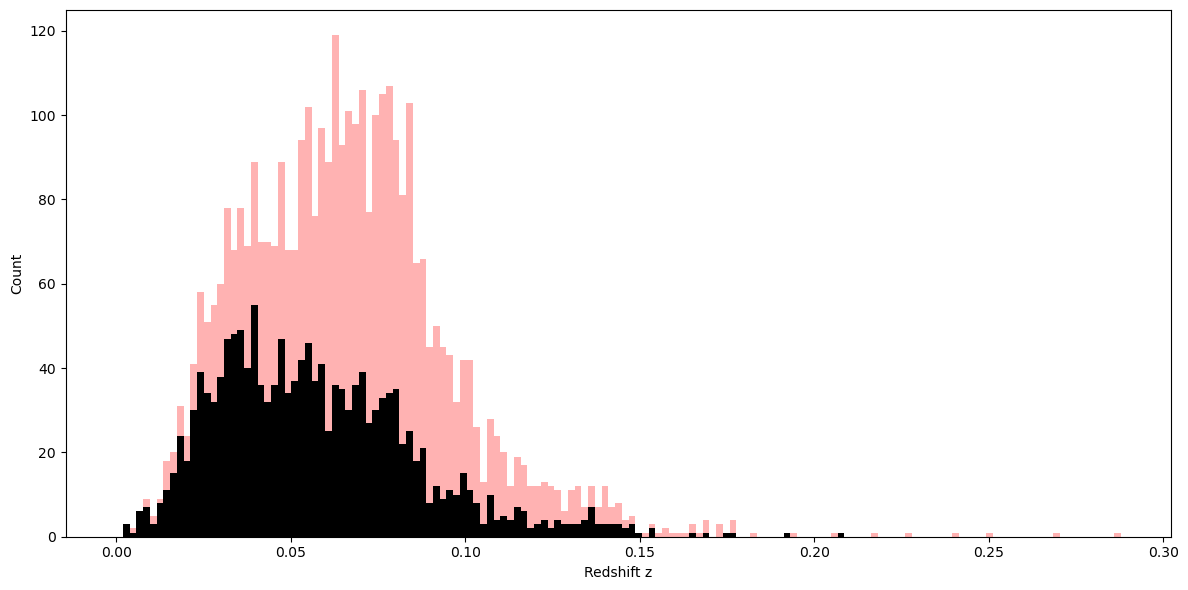

In [ ]:
DES_SN_CSV = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_snia_data.csv"
BLAST_CSV  = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_matches_props_v2_GLOBAL_ONLY.csv"

# Load
ZTF_sn   = pd.read_csv(DES_SN_CSV)
blast_df = pd.read_csv(BLAST_CSV)

print(len(ZTF_sn), "ZTF SNe Ia total")
matched = len(blast_df)
print(matched, "matched with BLAST data")

z_all_des      = pd.to_numeric(ZTF_sn["redshift"])
z_blast_subset = pd.to_numeric(blast_df["redshift"])

# Shared binning — one line!
zmin = 0
zmax = z_all_des.max()
bins = np.linspace(zmin, zmax, 150)   # <-- control bins right here

plt.figure(figsize=(12, 6))
plt.hist(z_all_des,      bins=bins, alpha=0.3, label="ZTF SNe Ia (zHEL)", color = "red")
plt.hist(z_blast_subset, bins=bins, alpha=1, label="BLAST-covered SNe Ia (zHEL)", color = "black")

plt.xlabel("Redshift z")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
DES_SN_CSV = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_snia_data.csv"
BLAST_CSV  = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_BLAST_matches_props_v2_ALL_HOST_PROPERTIES_LC_OK.csv"

# Load
ZTF_sn   = pd.read_csv(DES_SN_CSV)
blast_df = pd.read_csv(BLAST_CSV)

print(len(ZTF_sn), "ZTF SNe Ia total")
matched = len(blast_df)
print(matched, "matched with BLAST data")

z_all_des      = pd.to_numeric(ZTF_sn["redshift"])
z_blast_subset = pd.to_numeric(blast_df["redshift"])

# Shared binning — one line!
zmin = 0
zmax = z_all_des.max()
bins = np.linspace(zmin, zmax, 150)   # <-- control bins right here

plt.figure(figsize=(12, 6))
plt.hist(z_all_des,      bins=bins, alpha=0.3, label="ZTF SNe Ia (zHEL)", color = "red")
plt.hist(z_blast_subset, bins=bins, alpha=1, label="BLAST-covered SNe Ia (zHEL)", color = "black")

plt.xlabel("Redshift z")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined